# Atividade – Meios de transporte das mulheres (Brasil, 2022)



In [4]:

import matplotlib.pyplot as plt
import pandas as pd

arquivo = "Tabela_13_Meio_de_transporte.xlsx"

# A primeira linha é o título e a segunda contém os nomes das colunas.
df_brasil = pd.read_excel(arquivo, sheet_name="Exemplo gráfico Brasil", header=None)
df_brasil = df_brasil.iloc[2:].copy()
df_brasil.columns = ["Meio de transporte", "Branca", "Preta ou Parda", "Indígena"]
df_brasil = df_brasil.dropna(subset=["Meio de transporte"]).reset_index(drop=True)

# Garante que os percentuais sejam numéricos.
for coluna in ["Branca", "Preta ou Parda", "Indígena"]:
    df_brasil[coluna] = pd.to_numeric(df_brasil[coluna], errors="coerce")

df_brasil


,Meio de transporte,Branca,Preta ou Parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


In [5]:

df_brasil


,Meio de transporte,Branca,Preta ou Parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


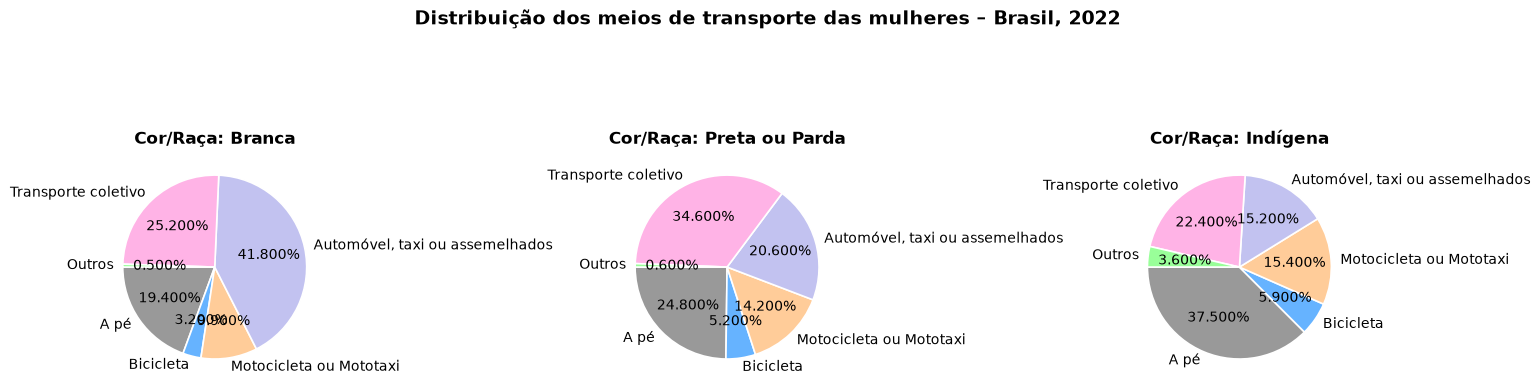

In [6]:


grupos = ["Branca", "Preta ou Parda", "Indígena"]
cores = ["#999999", "#66b3ff", "#ffcc99", "#c2c2f0", "#ffb3e6", "#99ff99"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(grupos):
    axes[i].pie(
        df_brasil[col],
        labels=df_brasil["Meio de transporte"],
        autopct="%1.3f%%",
        startangle=180,
        colors=cores[:len(df_brasil)],
        wedgeprops={"edgecolor": "white", "linewidth": 1.2}
    )
    axes[i].set_title(f"Cor/Raça: {col}", fontsize=12, fontweight="bold")

plt.suptitle(
    "Distribuição dos meios de transporte das mulheres – Brasil, 2022",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("grafico_transporte.png", dpi=300, bbox_inches="tight")
plt.show()


In [7]:


analise = df_brasil.melt(
    id_vars="Meio de transporte",
    var_name="Cor/Raça",
    value_name="Percentual"
)

tabela_diferencas = (
    analise.groupby("Meio de transporte")["Percentual"]
    .agg(["min", "max"])
    .assign(Diferença=lambda x: x["max"] - x["min"])
    .round(3)
)

tabela_diferencas


,min,max,Diferença
Meio de transporte,,,
A pé,19.4,37.5,18.1
"Automóvel, taxi ou assemelhados",15.2,41.8,26.6
Bicicleta,3.2,5.9,2.7
Motocicleta ou Mototaxi,9.9,15.4,5.5
Outros,0.5,3.6,3.1
Transporte coletivo,22.4,34.6,12.2


# Parte 2 – Estados e municípios




In [8]:

df = pd.read_excel(arquivo, sheet_name="BR GR UF MU", header=None)


dados = df.iloc[2:].copy()


modos = [
    "A pé",
    "Bicicleta",
    "Motocicleta ou Mototaxi",
    "Automóvel, taxi ou assemelhados",
    "Transporte coletivo",
    "Outros"
]
grupos = ["Branca", "Preta ou Parda", "Indígena"]

dados.columns = ["Local"] + [
    f"{grupo}_{modo}" for grupo in grupos for modo in modos
]

for coluna in dados.columns[1:]:
    dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce")

dados.head()


,Local,Branca_A pé,Branca_Bicicleta,Branca_Motocicleta ou Mototaxi,"Branca_Automóvel, taxi ou assemelhados",Branca_Transporte coletivo,Branca_Outros,Preta ou Parda_A pé,Preta ou Parda_Bicicleta,Preta ou Parda_Motocicleta ou Mototaxi,"Preta ou Parda_Automóvel, taxi ou assemelhados",Preta ou Parda_Transporte coletivo,Preta ou Parda_Outros,Indígena_A pé,Indígena_Bicicleta,Indígena_Motocicleta ou Mototaxi,"Indígena_Automóvel, taxi ou assemelhados",Indígena_Transporte coletivo,Indígena_Outros
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Brasil,19.4,3.2,9.9,41.8,25.2,0.5,24.8,5.2,14.2,20.6,34.6,0.6,37.5,5.9,15.4,15.2,22.4,3.6
4,Norte,15.2,5.9,24.5,35.1,17.9,1.3,21.3,8.6,27.7,19.5,20.8,2.1,46.8,4.8,19.2,9.5,9.1,10.6
5,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5,31.7,4.1,20.8,16.9,26.0,0.6,42.0,4.2,19.4,13.1,20.6,0.7
6,Sudeste,18.5,2.7,7.1,40.4,30.8,0.5,23.0,4.5,7.0,19.5,45.5,0.5,26.2,5.6,5.9,22.3,39.4,0.6


In [9]:


estados = [
    "Rondônia", "Acre", "Amazonas", "Roraima", "Pará", "Amapá", "Tocantins",
    "Maranhão", "Piauí", "Ceará", "Rio Grande do Norte", "Paraíba",
    "Pernambuco", "Alagoas", "Sergipe", "Bahia",
    "Minas Gerais", "Espírito Santo", "Rio de Janeiro", "São Paulo",
    "Paraná", "Santa Catarina", "Rio Grande do Sul",
    "Mato Grosso do Sul", "Mato Grosso", "Goiás", "Distrito Federal"
]

print("Estados encontrados na tabela:")
for estado in estados:
    print(estado)


Estados encontrados na tabela:
Rondônia
Acre
Amazonas
Roraima
Pará
Amapá
Tocantins
Maranhão
Piauí
Ceará
Rio Grande do Norte
Paraíba
Pernambuco
Alagoas
Sergipe
Bahia
Minas Gerais
Espírito Santo
Rio de Janeiro
São Paulo
Paraná
Santa Catarina
Rio Grande do Sul
Mato Grosso do Sul
Mato Grosso
Goiás
Distrito Federal


In [11]:

longa = dados.melt(
    id_vars="Local",
    var_name="Grupo_Modo",
    value_name="Percentual"
)


longa[["Cor/Raça", "Meio de transporte"]] = longa["Grupo_Modo"].str.split(
    "_", n=1, expand=True
)

longa.head()


,Local,Grupo_Modo,Percentual,Cor/Raça,Meio de transporte
0,NaN,Branca_A pé,NaN,Branca,A pé
1,Brasil,Branca_A pé,19.4,Branca,A pé
2,Norte,Branca_A pé,15.2,Branca,A pé
3,Nordeste,Branca_A pé,24.9,Branca,A pé
4,Sudeste,Branca_A pé,18.5,Branca,A pé


In [12]:

dados_estados = longa[longa["Local"].isin(estados)].copy()

media_estados = (
    dados_estados
    .groupby(["Local", "Meio de transporte"])["Percentual"]
    .mean()
    .reset_index(name="Percentual médio")
)


coletivo_estados = (
    media_estados[media_estados["Meio de transporte"] == "Transporte coletivo"]
    .sort_values("Percentual médio", ascending=False)
)

coletivo_estados


,Local,Meio de transporte,Percentual médio
125,Rio de Janeiro,Transporte coletivo,52.233333
41,Distrito Federal,Transporte coletivo,46.000000
155,São Paulo,Transporte coletivo,40.733333
119,Rio Grande do Sul,Transporte coletivo,36.100000
149,Sergipe,Transporte coletivo,33.400000
47,Espírito Santo,Transporte coletivo,32.633333
83,Paraná,Transporte coletivo,27.566667
77,Minas Gerais,Transporte coletivo,27.100000
53,Goiás,Transporte coletivo,25.100000
101,Pernambuco,Transporte coletivo,25.033333


In [14]:


estado_mais_coletivo = coletivo_estados.iloc[0]
estado_menos_coletivo = coletivo_estados.iloc[-1]

print(
    f"Estado com maior média de mulheres utilizando transporte coletivo: "
    f"{estado_mais_coletivo['Local']} ({estado_mais_coletivo['Percentual médio']:.2f}%)."
)

print(
    f"Estado com menor média de mulheres utilizando transporte coletivo: "
    f"{estado_menos_coletivo['Local']} ({estado_menos_coletivo['Percentual médio']:.2f}%)."
)


Estado com maior média de mulheres utilizando transporte coletivo: Rio de Janeiro (52.23%).
Estado com menor média de mulheres utilizando transporte coletivo: Rondônia (4.33%).


In [15]:

regioes = ["Brasil", "Norte", "Nordeste", "Sudeste", "Sul", "Centro-oeste"]

municipios = longa[
    ~longa["Local"].isin(regioes + estados)
].copy()


media_municipios = (
    municipios
    .groupby(["Local", "Meio de transporte"])["Percentual"]
    .mean()
    .reset_index(name="Percentual médio")
)


bicicleta = (
    media_municipios[media_municipios["Meio de transporte"] == "Bicicleta"]
    .sort_values("Percentual médio", ascending=False)
)


carro = (
    media_municipios[
        media_municipios["Meio de transporte"] == "Automóvel, taxi ou assemelhados"
    ]
    .sort_values("Percentual médio", ascending=False)
)

print(
    f"Cidade com maior média para bicicleta: "
    f"{bicicleta.iloc[0]['Local']} ({bicicleta.iloc[0]['Percentual médio']:.2f}%)."
)

print(
    f"Cidade com maior média para carro: "
    f"{carro.iloc[0]['Local']} ({carro.iloc[0]['Percentual médio']:.2f}%)."
)


Cidade com maior média para bicicleta: Tuiuti (SP) (100.00%).
Cidade com maior média para carro: Bom Jesus do Oeste (SC) (86.05%).
